**Initial plan: Add *'tenure_month'* column using *['BeginDate', 'EndDate']*, drop *'gender'* column**

*notes:*

target is 5,174 (active) : 1,869 (churned) / 7,043 (total)... (~27%)... class_weight='balanced'

stratify=target... maintain the ~27% imbalance environment for train/test sets

In [1]:
import pandas as pd
import numpy as np
import math as mt
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

data_contract = pd.read_csv('contract.csv')
data_internet = pd.read_csv('internet.csv')
data_personal = pd.read_csv('personal.csv')
data_phone = pd.read_csv('phone.csv')

display(data_contract.head())
display(data_internet.head())
display(data_personal.head())
display(data_phone.head())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [2]:
    #!! converting date columns to datetime format
warnings.filterwarnings('ignore')
data_contract['BeginDate'] = pd.to_datetime(data_contract['BeginDate'])
data_contract['EndDate'] = pd.to_datetime(data_contract['EndDate'], errors='coerce')
warnings.filterwarnings('default')

    #!! filling NaT (EndDate = 'No') with 'current day' (data set extraction date 2020-02-01)
data_contract['EndDate'] = data_contract['EndDate'].fillna(pd.Timestamp('2020-02-01'))

    #!! calculating tenure in months
data_contract['tenure_month'] = (data_contract['EndDate'] - data_contract['BeginDate']).dt.days // 30

    #!! dropping BeginDate (no relationship with customer loyalty)
data_contract = data_contract.drop('BeginDate', axis=1)

    #!! converting TotalCharges to numeric, coercing errors to NaN, then filling NaN with 0
data_contract['TotalCharges'] = pd.to_numeric(data_contract['TotalCharges'], errors='coerce')
data_contract['TotalCharges'] = data_contract['TotalCharges'].fillna(0)

    #!! converting EndDate to boolean (int64): 0 = active (2020-02-01), 1 = churned (other dates)
data_contract['EndDate'] = data_contract['EndDate'].apply(lambda x: 0 if x == pd.Timestamp('2020-02-01') else 1)

    #!! data_contract columns renamed, EndDate to churned, Type to contract_type, rest snake case
data_contract.rename(columns={'EndDate': 'churned', 'Type': 'contract_type', 'PaperlessBilling': 'paperless_billing',
                              'PaymentMethod': 'payment_method', 'MonthlyCharges': 'monthly_charges',
                              'TotalCharges': 'total_charges'}, inplace=True)

    #!! converting 'Yes'/'No' to 1/0
data_contract['paperless_billing'] = (data_contract['paperless_billing'] == 'Yes').astype(int)

#data_contract['high_risk'] = ((data_contract['tenure_month'] <= 12) & (data_contract['contract_type'] == 'Month-to-month') &
                              #(data_contract['payment_method'] == 'Electronic check')).astype(int)

display(data_contract.head())

,customerID,churned,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,tenure_month
0,7590-VHVEG,0,Month-to-month,1,Electronic check,29.85,29.85,1
1,5575-GNVDE,0,One year,0,Mailed check,56.95,1889.50,34
2,3668-QPYBK,1,Month-to-month,1,Mailed check,53.85,108.15,2
3,7795-CFOCW,0,One year,0,Bank transfer (automatic),42.30,1840.75,45
4,9237-HQITU,1,Month-to-month,1,Electronic check,70.70,151.65,2


In [3]:
#display(data_contract[data_contract['churned'] == 1].value_counts('contract_type'))
#display(data_contract[data_contract['churned'] == 1]['monthly_charges'].describe())
#display(data_contract[(data_contract['churned'] == 1) & (data_contract['contract_type'] == 'Month-to-month')]['tenure_month'].describe())
#display(data_contract[(data_contract['churned'] == 1) & (data_contract['contract_type'] == 'Month-to-month')]['payment_method'].value_counts())

**- *['tenure_month']* column added using 'BeginDate' & 'EndDate'... *['BeginDate']* dropped for reasons specified above... *['EndDate']* converted into binary int64 column where (0 = active, 1 = churned)... *['EndDate']* renamed to *['churned']*, and all columns converted to snake case (except customerID)... *['paperless_billing']* converted to binary column (1/0 - yes/no)**

In [4]:
    #!! data_internet columns renamed
data_internet.rename(columns={'InternetService': 'internet_service', 'OnlineSecurity': 'online_security',
                              'OnlineBackup': 'online_backup', 'DeviceProtection': 'device_protection',
                              'TechSupport': 'tech_support', 'StreamingTV': 'streaming_tv',
                              'StreamingMovies': 'streaming_movies'}, inplace=True)

**- all columns within the internet.csv data set have been converted to snake case**

In [5]:
    #!! dropping gender column (no relationship with customer loyalty)
data_personal = data_personal.drop('gender', axis=1)

    #!! data_personal columns renamed
data_personal.rename(columns={'SeniorCitizen': 'senior_citizen', 'Partner': 'partner',
                              'Dependents': 'dependents'}, inplace=True)

    #!! converting 'Yes'/'No' to 1/0
data_personal['partner'] = (data_personal['partner'] == 'Yes').astype(int)
data_personal['dependents'] = (data_personal['dependents'] == 'Yes').astype(int)

In [6]:
#display(data_personal.head(20))
#display(data_personal.info())

**- *['gender']* has been dropped from the peronal.csv data set, since it has no predictive power in the context of customer retention... all columns converted to snake case... *['partner', 'dependents']* converted to binary int64 (1/0 - yes/no)**

In [7]:
    #!! data_phone columns renamed
data_phone.rename(columns={'MultipleLines': 'multiple_lines'}, inplace=True)

**- snake case conversion for phone.csv column**

In [8]:
#data_contract.info()
#data_internet.info()
#data_personal.info()
#data_phone.info()

display(data_contract.head())
display(data_internet.head())
display(data_personal.head())
display(data_phone.head())

    #!! checking unique values
#for col in data_contract.select_dtypes(include=['object', 'int64']).columns: display(data_contract[col].value_counts())

    #!! checking unique values
#for col in data_internet.select_dtypes(include=['object']).columns: display(data_internet[col].value_counts())

    #!! checking unique values
#for col in data_personal.select_dtypes(include=['object', 'int64']).columns: display(data_personal[col].value_counts())

    #!! checking unique values
#for col in data_phone.select_dtypes(include=['object']).columns: display(data_phone[col].value_counts())

,customerID,churned,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,tenure_month
0,7590-VHVEG,0,Month-to-month,1,Electronic check,29.85,29.85,1
1,5575-GNVDE,0,One year,0,Mailed check,56.95,1889.50,34
2,3668-QPYBK,1,Month-to-month,1,Mailed check,53.85,108.15,2
3,7795-CFOCW,0,One year,0,Bank transfer (automatic),42.30,1840.75,45
4,9237-HQITU,1,Month-to-month,1,Electronic check,70.70,151.65,2


,customerID,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,senior_citizen,partner,dependents
0,7590-VHVEG,0,1,0
1,5575-GNVDE,0,0,0
2,3668-QPYBK,0,0,0
3,7795-CFOCW,0,0,0
4,9237-HQITU,0,0,0


,customerID,multiple_lines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


**- misc print and display loops to monitor the integrity of our features**

In [9]:
    #!! merging all dataframes on customerID
data = data_contract.merge(
    data_internet, on='customerID', how='left').merge(
        data_personal, on='customerID', how='left').merge(
            data_phone, on='customerID', how='left')

#data.info()
#display(data.head())
#display(data['multiple_lines'].value_counts())

    #!! creating family_plan feature: 1 if dependents & multiple_lines == 'Yes', else 0
#data['family_plan'] = ((data['dependents'] == 'Yes') & (data['multiple_lines'] == 'Yes')).astype(int)

add_ons = ['online_security', 'online_backup', 'device_protection',
            'tech_support', 'streaming_tv', 'streaming_movies']
data[add_ons] = data[add_ons].applymap(lambda x: 1 if x == 'Yes' else 0)
#data = data.drop('partner', axis=1)

    #!! filling 'No Service' for NaN values (customers without internet or phone service)
data.fillna('No Service', inplace=True)

    #!! creating binary columns for internet and phone service (0 = No Service, 1 = has service)
#data['has_internet'] = data['internet_service'].apply(lambda x: 0 if x == 'No Service' else 1)
#data['has_phone'] = data['multiple_lines'].apply(lambda x: 0 if x == 'No Service' else 1)

#data.info()
display(data.head())
#display(data['multiple_lines'].value_counts())

C:\Users\avonm\AppData\Local\Temp\ipykernel_21944\1673474117.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[add_ons] = data[add_ons].applymap(lambda x: 1 if x == 'Yes' else 0)


,customerID,churned,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,tenure_month,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,senior_citizen,partner,dependents,multiple_lines
0,7590-VHVEG,0,Month-to-month,1,Electronic check,29.85,29.85,1,DSL,0,1,0,0,0,0,0,1,0,No Service
1,5575-GNVDE,0,One year,0,Mailed check,56.95,1889.50,34,DSL,1,0,1,0,0,0,0,0,0,No
2,3668-QPYBK,1,Month-to-month,1,Mailed check,53.85,108.15,2,DSL,1,1,0,0,0,0,0,0,0,No
3,7795-CFOCW,0,One year,0,Bank transfer (automatic),42.30,1840.75,45,DSL,1,0,1,1,0,0,0,0,0,No Service
4,9237-HQITU,1,Month-to-month,1,Electronic check,70.70,151.65,2,Fiber optic,0,0,0,0,0,0,0,0,0,No


**- all 4 data sets merged on *'customerID'*, using contract.csv as the merge root... 'add_ons' concerning additional services have been converted to binary int64 (1/0 - yes/no)... *'No Service'* filling in missing values for *['internet_service', 'multiple_lines']* where customers have one or the other**

In [10]:
#display(data[data['churned'] == 1].value_counts('family_plan'))
#display(data.info())

In [11]:
    #!! OHE categorical features, dropping customerID
data_ohe = pd.get_dummies(data.drop('customerID', axis=1), drop_first=True)

    #!! splitting data into train and test sets (80/20), stratifying on target variable 'churned' (imbalanced classes)
data_train, data_test = train_test_split(data_ohe, test_size=0.2, random_state=777, stratify=data_ohe['churned'])

    #!! training set features and target
features_train = data_train.drop('churned', axis=1)
target_train = data_train['churned']

    #!! test set features and target
features_test = data_test.drop('churned', axis=1)
target_test = data_test['churned']

    #!! applying SMOTE class balancing to training set
#warnings.filterwarnings('ignore')
#smote = SMOTE(random_state=777)
#features_train, target_train = smote.fit_resample(features_train, target_train)
#warnings.filterwarnings('default')

    #!! initiating StandardScaler
numeric = ['monthly_charges', 'total_charges', 'tenure_month']
scaler = StandardScaler()
scaler.fit(features_train[numeric])

    #!! scaling non-binary numeric columns
features_train[numeric] = scaler.transform(features_train[numeric])
features_test[numeric] = scaler.transform(features_test[numeric])

#display(data_ohe.head())
#print(data_ohe.info())

display(data_train.head())
#print(data_train.info())
#print(data_train['churned'].value_counts())

display(data_test.head())
#print(data_test.info())
#print(data_test['churned'].value_counts())

display(features_train.head())
display(features_test.head())

,churned,paperless_billing,monthly_charges,total_charges,tenure_month,online_security,online_backup,device_protection,tech_support,streaming_tv,...,dependents,contract_type_One year,contract_type_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,internet_service_Fiber optic,internet_service_No Service,multiple_lines_No Service,multiple_lines_Yes
5886,0,0,19.75,948.9,47,0,0,0,0,0,...,1,False,True,False,False,True,False,True,False,False
3460,0,1,100.05,4834.0,48,0,0,1,1,1,...,0,False,False,True,False,False,True,False,False,False
4875,1,0,117.45,5438.9,48,1,1,1,1,1,...,0,False,False,False,True,False,True,False,False,True
5193,0,0,26.45,1914.5,73,0,0,0,0,0,...,0,False,True,True,False,False,False,True,False,True
1717,0,0,19.70,1421.9,73,0,0,0,0,0,...,0,False,True,True,False,False,False,True,False,False


,churned,paperless_billing,monthly_charges,total_charges,tenure_month,online_security,online_backup,device_protection,tech_support,streaming_tv,...,dependents,contract_type_One year,contract_type_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,internet_service_Fiber optic,internet_service_No Service,multiple_lines_No Service,multiple_lines_Yes
5970,0,1,89.15,413.25,5,1,0,0,0,0,...,0,False,False,False,True,False,True,False,False,True
3350,1,1,44.15,44.15,1,0,0,0,0,0,...,0,False,False,False,False,True,False,False,False,False
5115,0,0,65.65,3047.15,46,1,1,1,1,0,...,0,False,True,False,False,True,False,False,False,False
5437,1,1,61.60,1174.35,20,0,0,0,0,0,...,0,False,False,False,False,True,False,False,False,True
4725,1,0,62.05,62.05,1,0,0,1,1,0,...,0,False,False,False,False,True,False,False,False,True


,paperless_billing,monthly_charges,total_charges,tenure_month,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,...,dependents,contract_type_One year,contract_type_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,internet_service_Fiber optic,internet_service_No Service,multiple_lines_No Service,multiple_lines_Yes
5886,0,-1.484345,-0.584025,0.583743,0,0,0,0,0,0,...,1,False,True,False,False,True,False,True,False,False
3460,1,1.178155,1.137181,0.624126,0,0,1,1,1,1,...,0,False,False,True,False,False,True,False,False,False
4875,0,1.755085,1.405168,0.624126,1,1,1,1,1,1,...,0,False,False,False,True,False,True,False,False,True
5193,0,-1.262194,-0.156238,1.633705,0,0,0,0,0,0,...,0,False,True,True,False,False,False,True,False,True
1717,0,-1.486003,-0.374473,1.633705,0,0,0,0,0,0,...,0,False,True,True,False,False,False,True,False,False


,paperless_billing,monthly_charges,total_charges,tenure_month,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,...,dependents,contract_type_One year,contract_type_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,internet_service_Fiber optic,internet_service_No Service,multiple_lines_No Service,multiple_lines_Yes
5970,1,0.816745,-0.821333,-1.112351,1,0,0,0,0,1,...,0,False,False,False,True,False,True,False,False,True
3350,1,-0.675316,-0.984854,-1.273883,0,0,0,0,0,0,...,0,False,False,False,False,True,False,False,False,False
5115,0,0.037557,0.345557,0.543359,1,1,1,1,0,0,...,0,False,True,False,False,True,False,False,False,False
5437,1,-0.096728,-0.484144,-0.506603,0,0,0,0,0,1,...,0,False,False,False,False,True,False,False,False,True
4725,0,-0.081808,-0.976924,-1.273883,0,0,1,1,0,0,...,0,False,False,False,False,True,False,False,False,True


**- categorical features encoded using OHE... data split 80/20 into train/test sets, stratifying on our target variable to maintain the 27% churn class imbalance... train and test sets split into features/target... standard scaler fit on training set, non-binary numeric columns only *('monthly_charges', 'total_charges', 'tenure_month')*... training and test numeric features scaled... data ready for model training**

In [12]:
#!! function to evaluate classification model performance (Accuracy, F1, APS, ROC-AUC) with plots (F1, ROC, PRC)
def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(4)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

**- function from previous project used to evaluate binary classification models under various metrics... including the primary metrics used for this project evaluation (Accuracy, ROC-AUC >= .85)... modified for 4 decimal places**

## Baseline Model: DummyClassifier

           train    test
Accuracy  0.7346  0.7346
F1        0.0000  0.0000
APS       0.2654  0.2654
ROC AUC   0.5000  0.5000


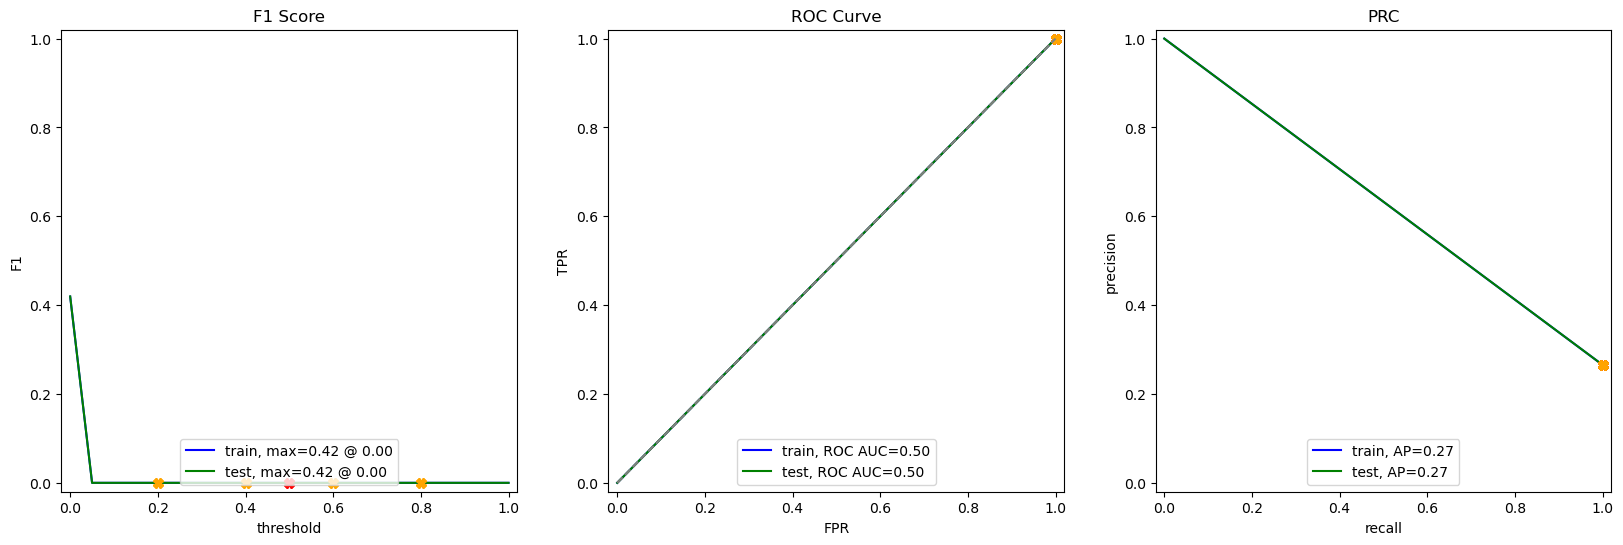

In [13]:
    #!! establishing baseline model (Dummy Classifier)
dummy_model = DummyClassifier(strategy='most_frequent', random_state=777)
dummy_model.fit(features_train, target_train)

evaluate_model(dummy_model, features_train, target_train, features_test, target_test)

**- As expected, predicting the majority class (0 = active) for every observation will result in being correct 73% of the time, this also means our model has no capability to distinguish between classes, hence the .50 ROC-AUC score**

## LogisticRegression

c:\Users\avonm\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


           train    test
Accuracy  0.7467  0.7537
F1        0.6260  0.6441
APS       0.6585  0.6560
ROC AUC   0.8472  0.8509


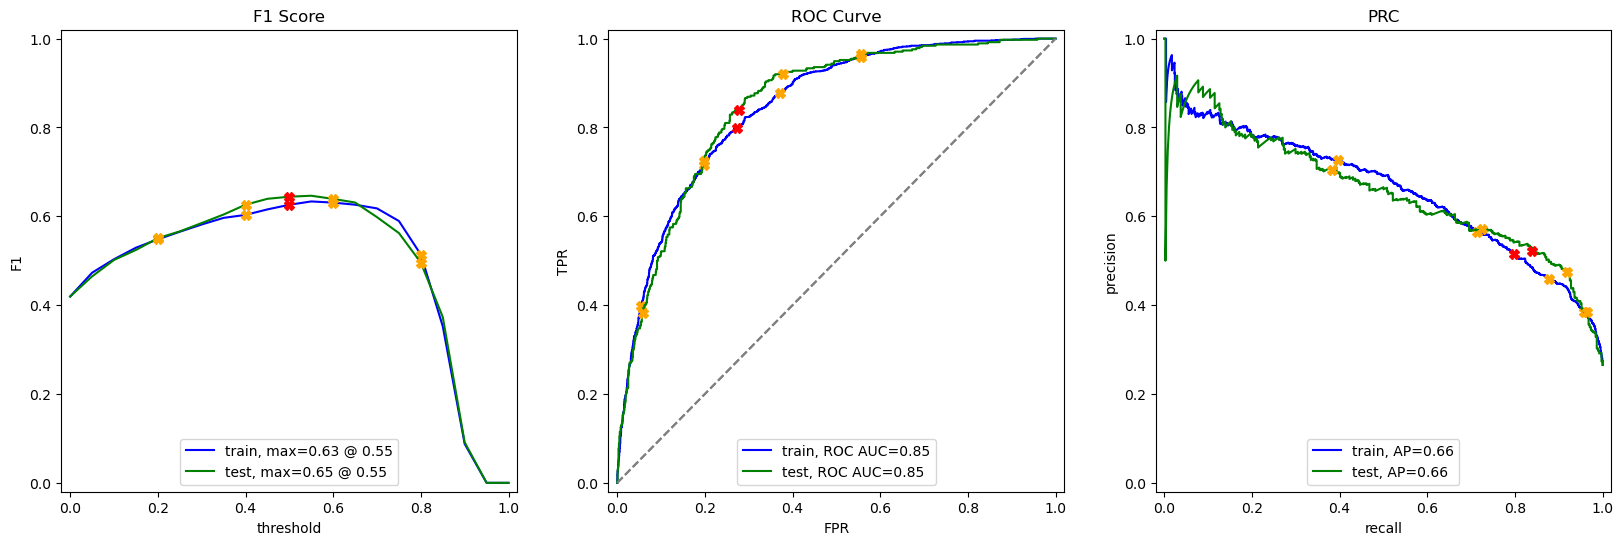

In [14]:
    #!! logistic regression model with balanced class weights
log_model = LogisticRegression(class_weight='balanced', random_state=777)
log_model.fit(features_train, target_train)

evaluate_model(log_model, features_train, target_train, features_test, target_test)

**- Our accuracy has improved by roughly 2% using LogisticRegression over DummyClassifier, with a ROC-AUC of .85 on tge test set. LogisticRegression will serve as our model to overcome moving forward**

## DecisionTreeClassifier

In [15]:
#!! looping through max_depth to find optimal value
best_model = None
best_score = 0
for depth in range(1, 21):
    tree_model = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=777)
    tree_model.fit(features_train, target_train)
    pred_prob = tree_model.predict_proba(features_test)[:, 1]
    roc_auc = metrics.roc_auc_score(target_test, pred_prob)
    if roc_auc > best_score:
        best_score = roc_auc
        best_model = tree_model

print('ROC-AUC of best model:', best_score)
print('Best Model:', best_model)

ROC-AUC of best model: 0.8325544447027824
Best Model: DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=777)


           train    test
Accuracy  0.7471  0.7189
F1        0.6438  0.6125
APS       0.6511  0.6146
ROC AUC   0.8608  0.8326


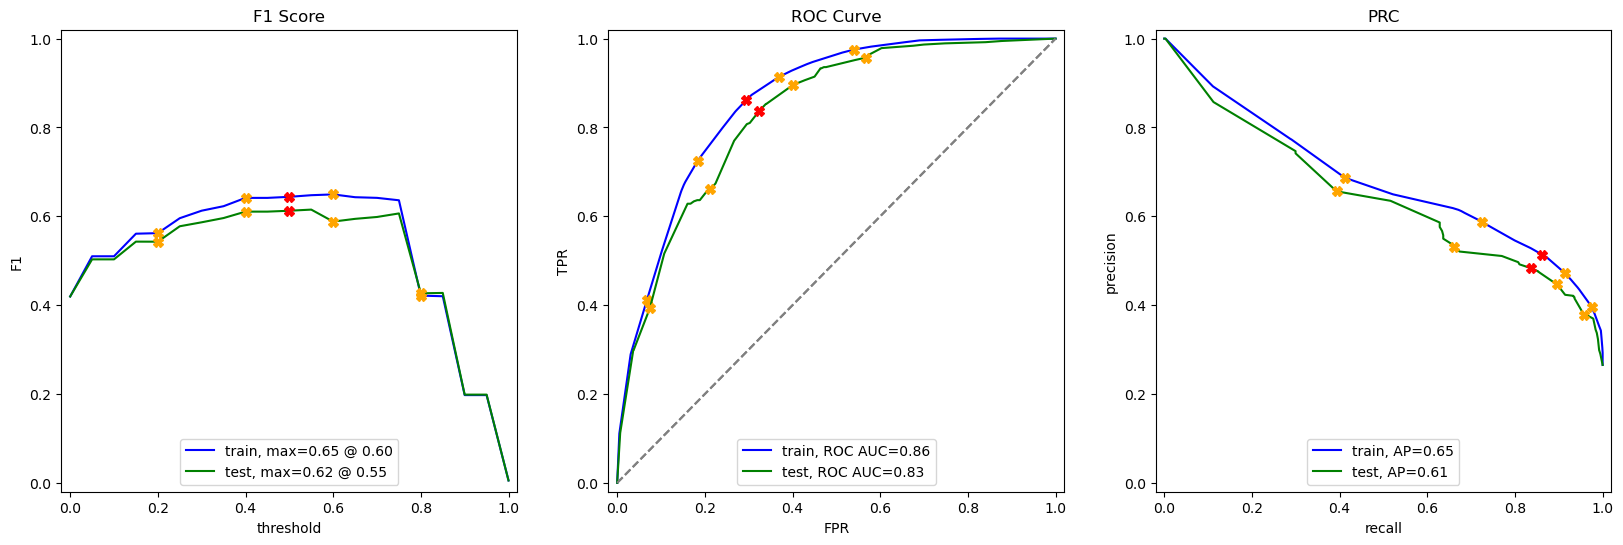

In [16]:
    #!! decision tree model with optimal max_depth
tree_model = best_model
tree_model.fit(features_train, target_train)

evaluate_model(tree_model, features_train, target_train, features_test, target_test)

**- DecisionTreeClassifier scored worse in both accuracy and ROC-AUC compared to LogisticRegression, so we will be moving onto RandomForest**

## RandomForestClassifier

In [17]:
#!! looping through n_estimators and max_depth to find optimal values
best_model = None
best_score = 0
for est in range(5, 55, 5):
    for depth in range(1, 21):
        rf_model = RandomForestClassifier(n_estimators=est, max_depth=depth, class_weight='balanced', random_state=777)
        rf_model.fit(features_train, target_train)
        pred_prob = rf_model.predict_proba(features_test)[:, 1]
        roc_auc = metrics.roc_auc_score(target_test, pred_prob)
        if roc_auc > best_score:
            best_score = roc_auc
            best_model = rf_model

print('ROC-AUC of best model:', best_score)
print('Best Model:', best_model)

ROC-AUC of best model: 0.8458627192642537
Best Model: RandomForestClassifier(class_weight='balanced', max_depth=6, n_estimators=20,
                       random_state=777)


           train    test
Accuracy  0.7703  0.7608
F1        0.6520  0.6471
APS       0.6949  0.6408
ROC AUC   0.8680  0.8459


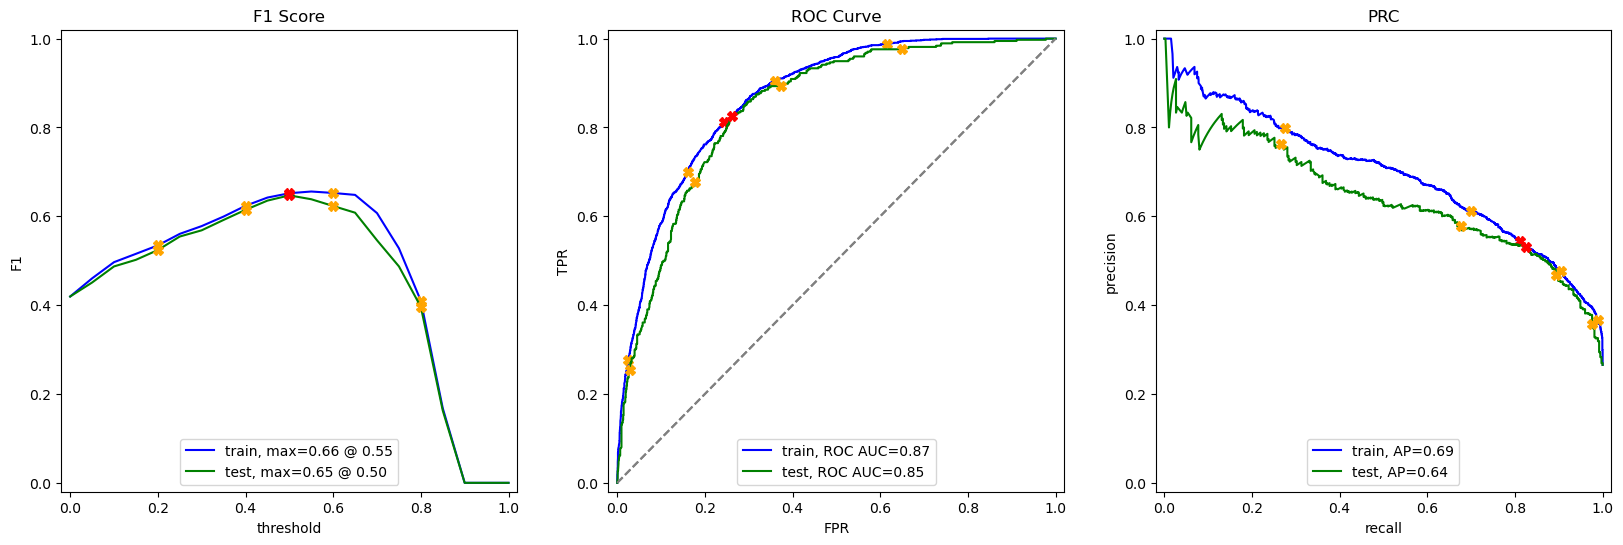

In [18]:
    #!! random forest model with optimal n_estimators and max_depth
rf_model = best_model
rf_model.fit(features_train, target_train)

evaluate_model(rf_model, features_train, target_train, features_test, target_test)

**- RandomForestClassifier performs noticably better than DecisionTreeClassifier, but still does not make it to the desired ROC-AUC of .85, we will be moving to more complex boosting models**

## XGBClassifier

c:\Users\avonm\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:49:33] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50}
Best ROC-AUC: 0.8426338828765308
           train    test
Accuracy  0.8220  0.7921
F1        0.6236  0.5554
APS       0.7153  0.6601
ROC AUC   0.8743  0.8510


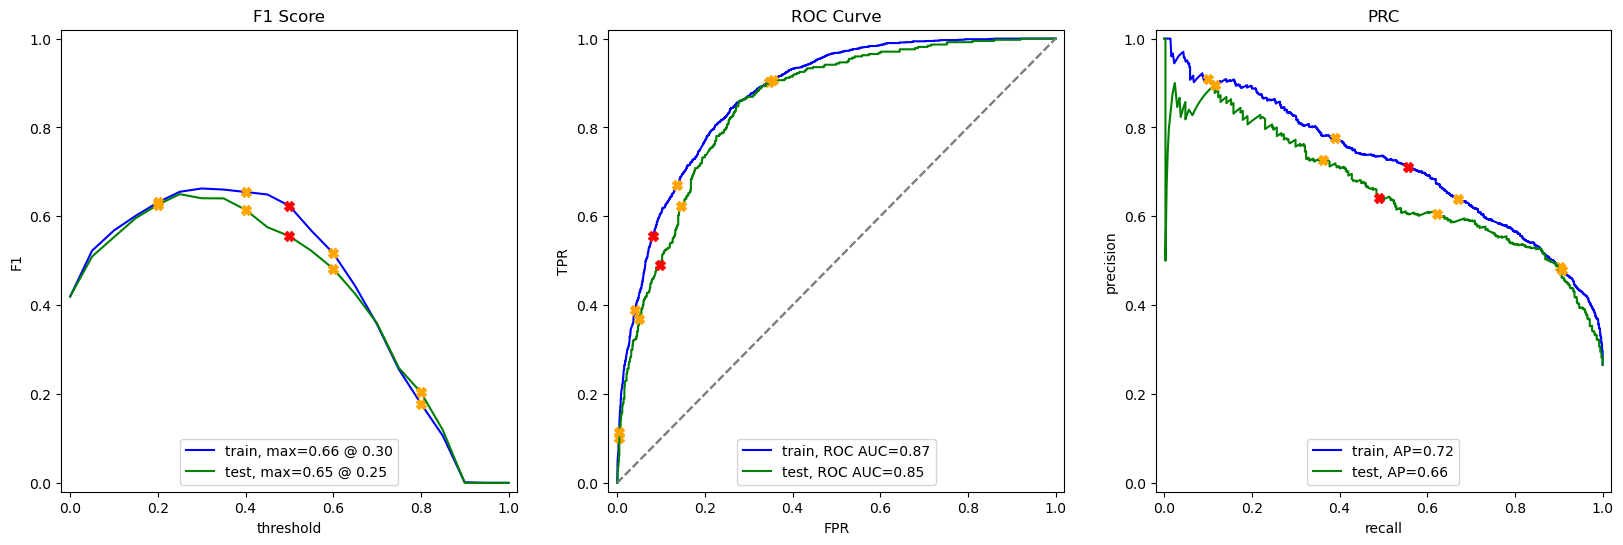

In [19]:
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(eval_metric='auc', use_label_encoder=False, random_state=777),
    param_grid=xgb_params,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=0
)

xgb_grid.fit(features_train, target_train)
print('Best parameters:', xgb_grid.best_params_)
print('Best ROC-AUC:', xgb_grid.best_score_)

evaluate_model(xgb_grid.best_estimator_, features_train, target_train, features_test, target_test)

#xgb_model = XGBClassifier(eval_metric='auc', random_state=777)
#xgb_model.fit(features_train, target_train)

#evaluate_model(xgb_model, features_train, target_train, features_test, target_test)

**- XGBoost is our first model to successfully cross the .85 ROC-AUC barrier, thanks to GridSearchCV !! truly magical, however, let's try another boost model, and then stack them in an ensemble to see if we can score higher**

## CatBoostClassifier

Best parameters: {'depth': 4, 'iterations': 200, 'loss_function': 'CrossEntropy'}
Best ROC-AUC: 0.8459820015777585


,feature,importance
3,tenure_month,20.131657
14,contract_type_Two year,18.829940
18,internet_service_Fiber optic,13.660870
19,internet_service_No Service,9.165998
2,total_charges,8.315147
1,monthly_charges,6.850720
13,contract_type_One year,5.021447
16,payment_method_Electronic check,3.909357
4,online_security,2.269547
0,paperless_billing,2.102752


           train    test
Accuracy  0.8156  0.8048
F1        0.6027  0.5776
APS       0.6953  0.6668
ROC AUC   0.8616  0.8528


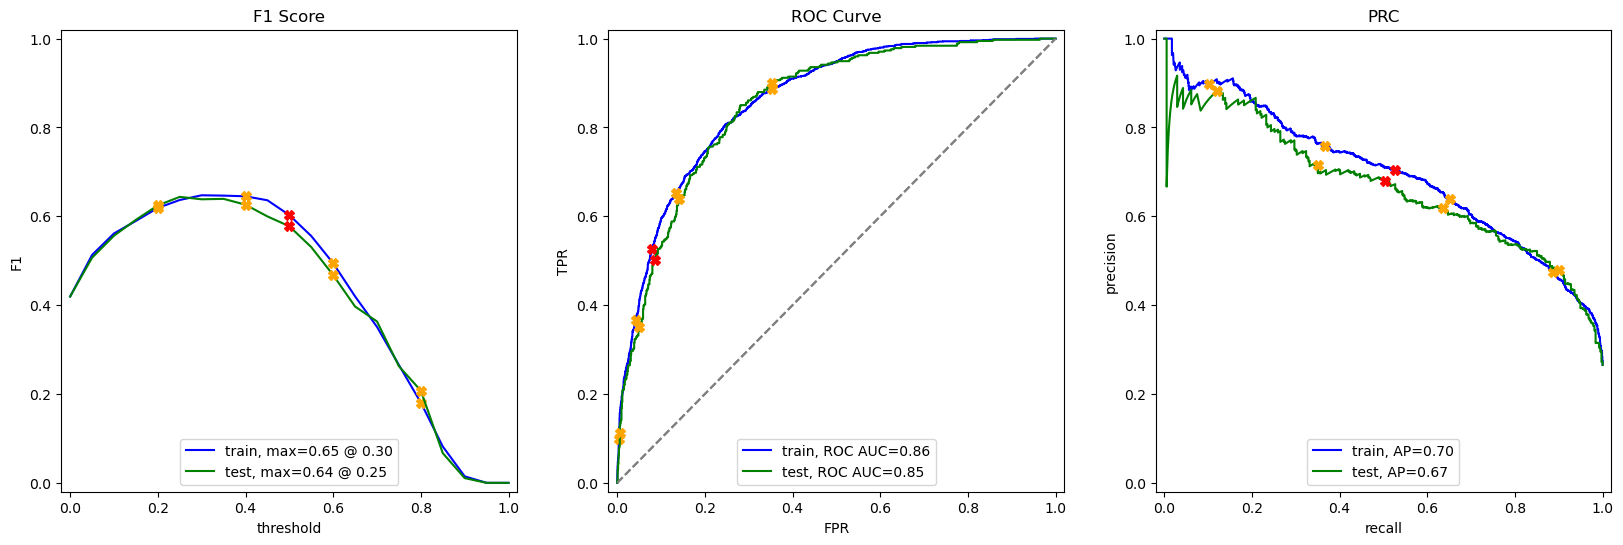

In [20]:
cbc_params = {
    'loss_function': ['Logloss', 'CrossEntropy'],
    'iterations': [50, 100, 200],
    'depth': [4, 6, 8],
}

cbc_grid = GridSearchCV(
    estimator=CatBoostClassifier(verbose=0, random_state=777),
    param_grid=cbc_params,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

cbc_grid.fit(features_train, target_train)
print('Best parameters:', cbc_grid.best_params_)
print('Best ROC-AUC:', cbc_grid.best_score_)

#cbc_model = CatBoostClassifier(verbose=0, random_state=777, loss_function='Logloss', iterations=100)
#cbc_model.fit(features_train, target_train)

important = cbc_grid.best_estimator_.get_feature_importance()
names = features_train.columns
important_features = pd.DataFrame({'feature': names, 'importance': important}).sort_values(by='importance', ascending=False)
display(important_features.head(30))

evaluate_model(cbc_grid.best_estimator_, features_train, target_train, features_test, target_test)

**- Accuracy above .80 AND ROC-AUC above .85 ! We're truly making strides here, maybe we can score even better if we combine XGBoost and CatBoost**

## Ensemble: RandomForest, XGBoost, CatBoost

           train    test
Accuracy  0.8184  0.8034
F1        0.6138  0.5758
APS       0.7067  0.6658
ROC AUC   0.8689  0.8530


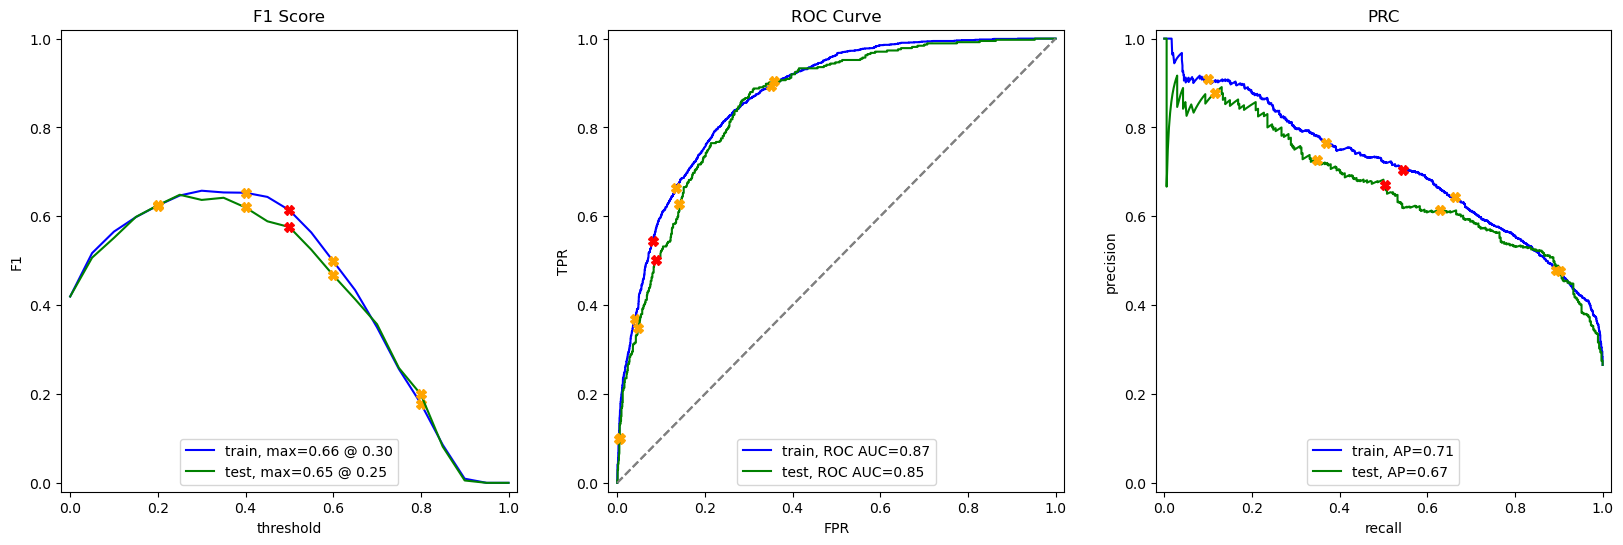

In [21]:
ensemble = VotingClassifier([
    ('xgb', XGBClassifier(eval_metric='auc', random_state=777,
                           n_estimators=xgb_grid.best_params_['n_estimators'],
                           max_depth=xgb_grid.best_params_['max_depth'],
                           learning_rate=xgb_grid.best_params_['learning_rate'])),
    ('cbc', CatBoostClassifier(verbose=0, random_state=777,
                               loss_function=cbc_grid.best_params_['loss_function'],
                               iterations=cbc_grid.best_params_['iterations'],
                               depth=cbc_grid.best_params_['depth']))
], voting='soft')

ensemble.fit(features_train, target_train)
evaluate_model(ensemble, features_train, target_train, features_test, target_test)

**- utilizing a stack ensemble, we've managed to beat out our highest individual boost model ROC-AUC score (CatBoost: .8528) vs (Ensemble: .8530)... Although CatBoost achieves a higher Accuracy score on it's own, Accuracy is second to ROC-AUC, therefore I'm choosing the stack ensemble... On large enough sample sizes, this almost inconcievable difference could mean missing hundreds of customers**

## **Conclusion:**

- Majority of my time with this project was fine-tuning existing features, and adding new ones with feature engineering. However, in many cases, the features implemented either harmed metric scores, or did not provide a remarkable performance boost. The only feature that proved worthy to our models was ['tenure_month'], which provided significant value to churn prediction.

***Some features that were added but later removed include:***

- ['family_plan'] = ('multiple_lines' == yes) + ('dependents' == yes)
- ['high_risk'] = ('contract_type' == 'Month-to-Month') + ('tenure_month' <= 12) + ('payment_method' == 'Electronic check')
- ['has_internet', 'has_phone'] = covering customers who have one service and not the other, removed after introducing binary conversion to 'add_ons', and multicollinerity with 'No service' within 'internet_service' and 'multiple_lines'

***SMOTE was implemented, which drastically helped the models on the train set, but harmed them on the test set***

**- In the end we achieved an Accuracy rating of 80.34%, and an ROC-AUC of 85.30% against the test set utilizing an ensemble stack of XGBClassifier and CatBoostClassifier**

- model details below:

In [22]:
ensemble = VotingClassifier([
    ('xgb', XGBClassifier(eval_metric='auc', random_state=777,
                          n_estimators=50, max_depth=4, learning_rate=0.1)),
    ('cbc', CatBoostClassifier(verbose=0, random_state=777,
                                depth=4, iterations=200, loss_function='CrossEntropy'))
], voting='soft')